# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

## BFI analysis

In [4]:
msts_bfi_vehicle = pl.read_csv(PREPARED_FILES["bfi_vehicle"])
msts_bfi_empa = pl.read_csv(PREPARED_FILES["bfi_empa"])
msts_bfi_vehicle.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,treatment,bfi_baseline,bfi_change,bfi_injected,log_bfi_baseline,log_bfi_injected,log_bfi_baseline_std,log_bfi_change
str,f64,str,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64
"""count""",763.0,"""763""","""763""","""763""","""763""",763.0,"""763""",763.0,763.0,763.0,763.0,763.0,763.0,763.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",396.760157,null,null,null,null,12.087811,null,60.508247,3.396842,63.905089,4.082197,4.135394,-0.087787,0.053196
"""std""",225.030033,null,null,null,null,8.071947,null,12.346811,3.832176,13.554967,0.203315,0.209763,0.978514,0.059407
"""min""",15.0,"""20240813a""","""fa/+""","""Adult""","""F""",0.0,"""Vehicle""",29.043812,-7.538559,33.834568,3.368805,3.521483,-3.521196,-0.11578
"""25%""",205.0,null,null,null,null,5.0,null,50.708885,0.664391,53.904743,3.926101,3.987218,-0.839046,0.011429
"""50%""",385.0,null,null,null,null,11.0,null,59.074081,3.135319,61.920944,4.078792,4.125858,-0.104175,0.051714
"""75%""",589.0,null,null,null,null,18.0,null,68.218925,6.059395,72.643837,4.222722,4.285569,0.588529,0.098368
"""max""",825.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,"""Vehicle""",102.490929,20.555809,109.41053,4.629774,4.695107,2.547588,0.251871


In [5]:
idata_bfi_empa = az.from_netcdf(RESULTS_DIR / "idata_bfi_empa.nc")
idata_bfi_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bfi_vehicle.nc")
idata_bfi_bsl = az.from_netcdf(RESULTS_DIR / "idata_bfi_baseline_extra_interaction.nc")

idata_bfi_empa

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

# Compute group values

In [6]:
t_groups_empa, t_groups_vehicle = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_bfi_empa, idata_bfi_vehicle)
)
t_groups_bsl = {
    "fa/+:female:adult":   idata_bfi_bsl.posterior["Intercept"],
    
    "fa/+:female:young":   idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["age"],
    
    "fa/+:male:adult":     idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["sex"],
    
    "fa/+:male:young":     idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["sex"] + idata_bfi_bsl.posterior["age"] + idata_bfi_bsl.posterior["gtyp:age:sex"].sel({"gtyp:age:sex_dim": 'fa/+, Young, M'}),
    
    "fa/fa:female:adult":  idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["gtyp"],
    
    "fa/fa:female:young":  idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["gtyp"] + idata_bfi_bsl.posterior["age"] + idata_bfi_bsl.posterior["gtyp:age"],
    
    "fa/fa:male:adult":    idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["gtyp"] + idata_bfi_bsl.posterior["sex"] + idata_bfi_bsl.posterior["gtyp:sex"],
   
    "fa/fa:male:young":    idata_bfi_bsl.posterior["Intercept"] + idata_bfi_bsl.posterior["gtyp"] + idata_bfi_bsl.posterior["sex"] + idata_bfi_bsl.posterior["gtyp:sex"] + idata_bfi_bsl.posterior["age"] + idata_bfi_bsl.posterior["gtyp:age"] + idata_bfi_bsl.posterior["gtyp:age:sex"].sel({"gtyp:age:sex_dim": 'fa/fa, Young, M'}),
} 


## Show TS for groups

In [8]:
ts_empa, ts_vehicle, ts_bsl = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_empa, t_groups_vehicle, t_groups_bsl)
)

sign_probabilities_bfi_change = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()}
})

print("Sign probabilities for Change after Empa:")
display(get_sign_probs(ts_empa))
print("Sign probabilities for Change after Vehicle:")
display(get_sign_probs(ts_vehicle))

Sign probabilities for Change after Empa:


{'fa/fa adult M': 0.0005,
 'fa/fa young M': 0.00025,
 'fa/+ adult M': 0.0,
 'fa/+ young M': 0.0,
 'fa/fa adult F': 0.00225,
 'fa/fa young F': 0.00025,
 'fa/+ adult F': 0.0,
 'fa/+ young F': 0.0}

Sign probabilities for Change after Vehicle:


{'fa/fa adult M': 0.9205,
 'fa/fa young M': 0.94075,
 'fa/+ adult M': 0.3105,
 'fa/+ young M': 0.82325,
 'fa/fa adult F': 0.99675,
 'fa/fa young F': 0.9985,
 'fa/+ adult F': 1.0,
 'fa/+ young F': 0.999}

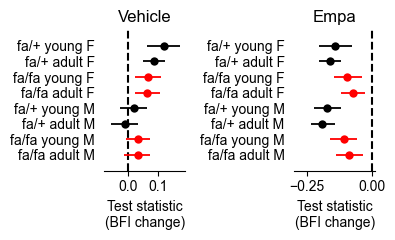

In [10]:
f, axes = plt.subplots(1, 2, figsize=(4, 2.5))
axes[1] = forestplot_oz(axes[1], ts_empa);
axes[1].set_title("Empa");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(BFI change)')

axes[1].set_xlim(-0.3, 0.01)
axes[0].set_xlim(-0.08, 0.19)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_bfi_groups.pdf", bbox_inches="tight")

## TS representing the difference between fa/fa and fa/+ 

In [11]:
ts_empa, ts_vehicle, ts_bsl = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        "overall": ((t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2 \
                     + (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2)/2,
        
    }
    for t_groups in (t_groups_empa, t_groups_vehicle, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
    'baseline1':get_sign_probs(ts_bsl),
    'baseline1_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_bsl).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))
print("\nBaseline 1 sign probabilities:")
display(get_sign_probs(ts_bsl))

Empa sign probabilities:


{'M adult': 0.99775,
 'M young': 0.96275,
 'F adult': 0.99525,
 'F young': 0.88325,
 'overall': 0.99975}


Vehicle sign probabilities:


{'M adult': 0.9145,
 'M young': 0.6655,
 'F adult': 0.19275,
 'F young': 0.056,
 'overall': 0.36775}


Baseline 1 sign probabilities:


{'M adult': 0.7215,
 'M young': 0.79275,
 'F adult': 0.00025,
 'F young': 0.64225,
 'overall': 0.23925}

[]

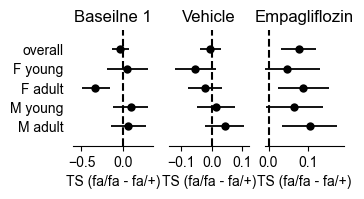

In [13]:
f, axes = plt.subplots(1, 3, figsize=(3.5, 1.5))
plt.subplots_adjust(wspace=0.2)

for ax, ts_, tle in zip(axes, (ts_bsl, ts_vehicle, ts_empa), ('Baseilne 1', 'Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (fa/fa - fa/+)')
    
axes[0].set_xlim(-0.6,0.35)
axes[1].set_xlim(-0.14, 0.12)
axes[2].set_xlim(-0.01, 0.19)

axes[2].set_yticks([],[])
axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_bfi_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## TS representing the difference between males and females

In [27]:
ts_empa, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_empa, t_groups_vehicle)
)

ts_bsl = {
    "M fa/fa":  t_groups_bsl["fa/fa:male:young"] -   t_groups_bsl["fa/fa:male:adult"],
    "M fa/+":   t_groups_bsl["fa/+:male:young"] -    t_groups_bsl["fa/+:male:adult"],
    "F fa/fa":  t_groups_bsl["fa/fa:female:young"] - t_groups_bsl["fa/fa:female:adult"],
    "F fa/+":   t_groups_bsl["fa/+:female:young"] -  t_groups_bsl["fa/+:female:adult"],
}

sign_probabilities_age = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
    'baseline1':get_sign_probs(ts_bsl),
    'baseline1_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_bsl).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))
print("\nBaseline 1 sign probabilities:")
display(get_sign_probs(ts_bsl))

Empa sign probabilities:


{'fa/fa': 0.247, 'fa/+': 0.7485}


Vehicle sign probabilities:


{'fa/fa': 0.516, 'fa/+': 0.8835}


Baseline 1 sign probabilities:


{'M fa/fa': 0.65075, 'M fa/+': 0.55075, 'F fa/fa': 0.68, 'F fa/+': 0.00225}

(-0.09, 0.1)

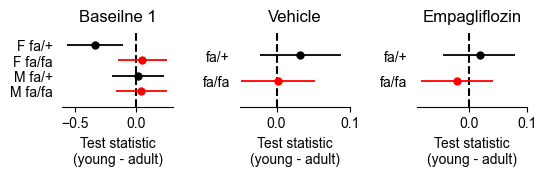

In [28]:
f, axes = plt.subplots(1, 3, figsize=(6, 1))
plt.subplots_adjust(wspace=0.6)

for ax, ts_, tle in zip(axes, (ts_bsl, ts_vehicle, ts_empa), ('Baseilne 1', 'Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(young - adult)')
    
axes[0].set_xlim(-0.6,0.3)
axes[1].set_xlim(-0.05, 0.1)
axes[2].set_xlim(-0.09, 0.1)

# axes[2].set_yticks([],[])
# axes[1].set_yticks([],[])
# f.savefig(PLOT_DIR / "ts_bfi_CompareAgesForGtypSexes.pdf", bbox_inches="tight")

## TS representing difference between male and female

In [29]:
ts_empa, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_empa, t_groups_vehicle)
)

ts_bsl = {
    "adult fa/fa":  t_groups_bsl["fa/fa:male:adult"] - t_groups_bsl["fa/fa:female:adult"],
    "young fa/fa":  t_groups_bsl["fa/fa:male:young"] - t_groups_bsl["fa/fa:female:young"],
    "adult fa/+":   t_groups_bsl["fa/+:male:adult"] -  t_groups_bsl["fa/+:female:adult"],
    "young fa/+":   t_groups_bsl["fa/+:male:young"] -  t_groups_bsl["fa/+:female:young"],
}

sign_probabilities_sex = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
    'baseline1':get_sign_probs(ts_bsl),
    'baseline1_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_bsl).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))
print("\nBaseline 1 sign probabilities:")
display(get_sign_probs(ts_bsl))

Empa sign probabilities:


{'fa/fa': 0.321, 'fa/+': 0.13775}


Vehicle sign probabilities:


{'fa/fa': 0.1015, 'fa/+': 0.0005}


Baseline 1 sign probabilities:


{'adult fa/fa': 0.991,
 'young fa/fa': 0.9885,
 'adult fa/+': 0.05175,
 'young fa/+': 0.94525}

(-0.11, 0.06)

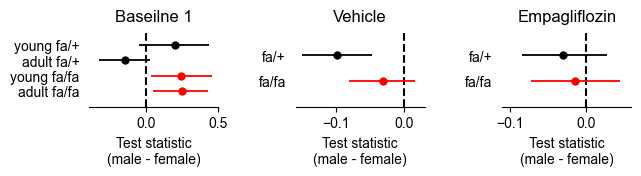

In [30]:
f, axes = plt.subplots(1, 3, figsize=(7, 1))
plt.subplots_adjust(wspace=0.6)

for ax, ts_, tle in zip(axes, (ts_bsl, ts_vehicle, ts_empa), ('Baseilne 1', 'Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
axes[0].set_xlim(-0.4,0.5)
axes[1].set_xlim(-0.16, 0.03)
axes[2].set_xlim(-0.11, 0.06)

# axes[2].set_yticks([],[])
# axes[1].set_yticks([],[])
# f.savefig(PLOT_DIR / "ts_bfi_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [31]:
sp_all = pd.concat(objs=(sign_probabilities_bfi_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('bfi change',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/mean_bfi.csv')
sp_all

empa empa_signif  vehicle vehicle_signif  \
contrast      group                                                        
bfi change    fa/fa adult M  0.00050           *  0.92050                  
              fa/fa young M  0.00025           *  0.94075                  
              fa/+ adult M   0.00000           *  0.31050                  
              fa/+ young M   0.00000           *  0.82325                  
              fa/fa adult F  0.00225           *  0.99675              *   
              fa/fa young F  0.00025           *  0.99850              *   
              fa/+ adult F   0.00000           *  1.00000              *   
              fa/+ young F   0.00000           *  0.99900              *   
fa/fa - fa/+  M adult        0.99775           *  0.91450                  
              M young        0.96275              0.66550                  
              F adult        0.99525           *  0.19275                  
              F young        0.88325              0.05600                  
              overall        0.99975           *  0.36775                  
young - adult fa/fa          0.24700              0.51600                  
              fa/+           0.74850              0.88350                  
              M fa/fa            NaN         NaN      NaN            NaN   
              M fa/+             NaN         NaN      NaN            NaN   
              F fa/fa            NaN         NaN      NaN            NaN   
              F fa/+             NaN         NaN      NaN            NaN   
male - female fa/fa          0.32100              0.10150                  
              fa/+           0.13775              0.00050              *   
              adult fa/fa        NaN         NaN      NaN            NaN   
              young fa/fa        NaN         NaN      NaN            NaN   
              adult fa/+         NaN         NaN      NaN            NaN   
              young fa/+         NaN         NaN      NaN            NaN   

                             baseline1 baseline1_signif  
contrast      group                                      
bfi change    fa/fa adult M        NaN              NaN  
              fa/fa young M        NaN              NaN  
              fa/+ adult M         NaN              NaN  
              fa/+ young M         NaN              NaN  
              fa/fa adult F        NaN              NaN  
              fa/fa young F        NaN              NaN  
              fa/+ adult F         NaN              NaN  
              fa/+ young F         NaN              NaN  
fa/fa - fa/+  M adult          0.72150                   
              M young          0.79275                   
              F adult          0.00025                *  
              F young          0.64225                   
              overall          0.23925                   
young - adult fa/fa                NaN              NaN  
              fa/+                 NaN              NaN  
              M fa/fa          0.65075                   
              M fa/+           0.55075                   
              F fa/fa          0.68000                   
              F fa/+           0.00225                *  
male - female fa/fa                NaN              NaN  
              fa/+                 NaN              NaN  
              adult fa/fa      0.99100                *  
              young fa/fa      0.98850                *  
              adult fa/+       0.05175                   
              young fa/+       0.94525